In [1]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

import cartopy.crs as ccrs
import cartopy.feature as cfeature

import cmaps  # 自定义 colormap

from pathlib import Path
import intake
# Set data path
data_path = Path('/work/mh1498/m301257/')
import os
fig_save_dir = "./figures/Cal_trop_wmo/"
os.makedirs(fig_save_dir, exist_ok=True)

In [2]:
# 导入必要的库
import metpy.calc as mpcalc
from metpy.units import units
# data_path = Path('/work/mh1498/m301257/')
# 热带区域定义
TROPICAL_BOUNDS = (-15, 15)  # 15°S - 15°N
G = 9.81  # 重力加速度 (m/s²)

# 读取陆地mask (0=ocean, 1=land)
print("读取陆地mask...")
land_mask = xr.open_dataset(data_path / 'processed_data/land_mask_2deg.nc')
ocean_mask = land_mask['__xarray_dataarray_variable__'] == 0  # 海洋为True
print(f"✓ Ocean grid points: {ocean_mask.sum().values}/{ocean_mask.size}")

# ptop
ta_cntl = xr.open_dataset(data_path / 'ta_cntl_layers/ta_all_levels.nc')
print("\n读取温度数据...")
ptop_cntl = xr.open_dataset(data_path / 'ptop_CNTL_processed.nc')
ptop_p4k = xr.open_dataset(data_path / 'ptop_P4K_processed.nc')
ptop_4co2 = xr.open_dataset(data_path / 'ptop_4CO2_processed.nc')


lat_dim = 'lat' if 'lat' in ptop_cntl.data_vars else 'latitude'
lon_dim = 'lon' if 'lon' in ptop_cntl.data_vars else 'longitude'

# 检测垂直维度名称
if 'lev' in ptop_cntl.data_vars:
    lev_dim = 'lev'
elif 'plev' in ptop_cntl.data_vars:
    lev_dim = 'plev'
elif 'level' in ptop_cntl.data_vars:
    lev_dim = 'level'
else:
    lev_dim = [d for d in ptop_cntl.data_vars if d not in ['time', lat_dim, lon_dim]][0]



读取陆地mask...
✓ Ocean grid points: 2089/2700

读取温度数据...


In [3]:
ta_cntl

<xarray.Dataset> Size: 2GB
Dimensions:  (level: 22, time: 5114, lat: 15, lon: 180)
Coordinates:
  * level    (level) int64 176B 31 35 38 41 46 51 55 58 ... 81 83 84 85 87 89 90
  * time     (time) datetime64[ns] 41kB 1980-01-01 1980-01-02 ... 1993-12-31
  * lat      (lat) float64 120B -14.0 -12.0 -10.0 -8.0 ... 8.0 10.0 12.0 14.0
  * lon      (lon) float64 1kB 0.0 2.0 4.0 6.0 8.0 ... 352.0 354.0 356.0 358.0
Data variables:
    ta       (level, time, lat, lon) float64 2GB ...

In [4]:
pfull_cntl = xr.open_dataset(data_path / 'pfull_cntl_layers/pfull_all_levels.nc')
pfull_cntl

<xarray.Dataset> Size: 2GB
Dimensions:  (level: 22, time: 5114, lat: 15, lon: 180)
Coordinates:
  * level    (level) int64 176B 31 35 38 41 46 51 55 58 ... 81 83 84 85 87 89 90
  * time     (time) datetime64[ns] 41kB 1980-01-01 1980-01-02 ... 1993-12-31
  * lat      (lat) float64 120B -14.0 -12.0 -10.0 -8.0 ... 8.0 10.0 12.0 14.0
  * lon      (lon) float64 1kB 0.0 2.0 4.0 6.0 8.0 ... 352.0 354.0 356.0 358.0
Data variables:
    pfull    (level, time, lat, lon) float64 2GB ...

In [5]:

ptop_cntl


<xarray.Dataset> Size: 110MB
Dimensions:  (time: 5114, lat: 15, lon: 180)
Dimensions without coordinates: time, lat, lon
Data variables:
    ptop     (time, lat, lon) float64 110MB ...

In [6]:
ptop_4co2

<xarray.Dataset> Size: 110MB
Dimensions:  (ncl0: 5114, ncl1: 15, ncl2: 180)
Dimensions without coordinates: ncl0, ncl1, ncl2
Data variables:
    ptop     (ncl0, ncl1, ncl2) float64 110MB ...

In [7]:
ptop_p4k

<xarray.Dataset> Size: 110MB
Dimensions:  (time: 5114, lat: 15, lon: 180)
Dimensions without coordinates: time, lat, lon
Data variables:
    ptop     (time, lat, lon) float64 110MB ...

In [8]:
time_coords = ta_cntl['time'].values
lat_coords = ta_cntl['lat'].values
lon_coords = ta_cntl['lon'].values

ptop_4co2 = ptop_4co2.rename({'ncl0': 'time', 'ncl1': 'lat', 'ncl2': 'lon'})

# 2. 重新设置 ptop 的坐标（确保维度名一致）
for ds in [ptop_cntl, ptop_p4k, ptop_4co2]:
    ds['ptop'] = ds['ptop'].assign_coords(
        time=time_coords,
        lat=lat_coords,
        lon=lon_coords
    )



## 计算ptop的气候态平均

In [9]:
ptop_mean_cntl  = ptop_cntl.ptop.mean('time')
ptop_mean_p4k   = ptop_p4k.ptop.mean('time')
ptop_mean_4co2  = ptop_4co2.ptop.mean('time')

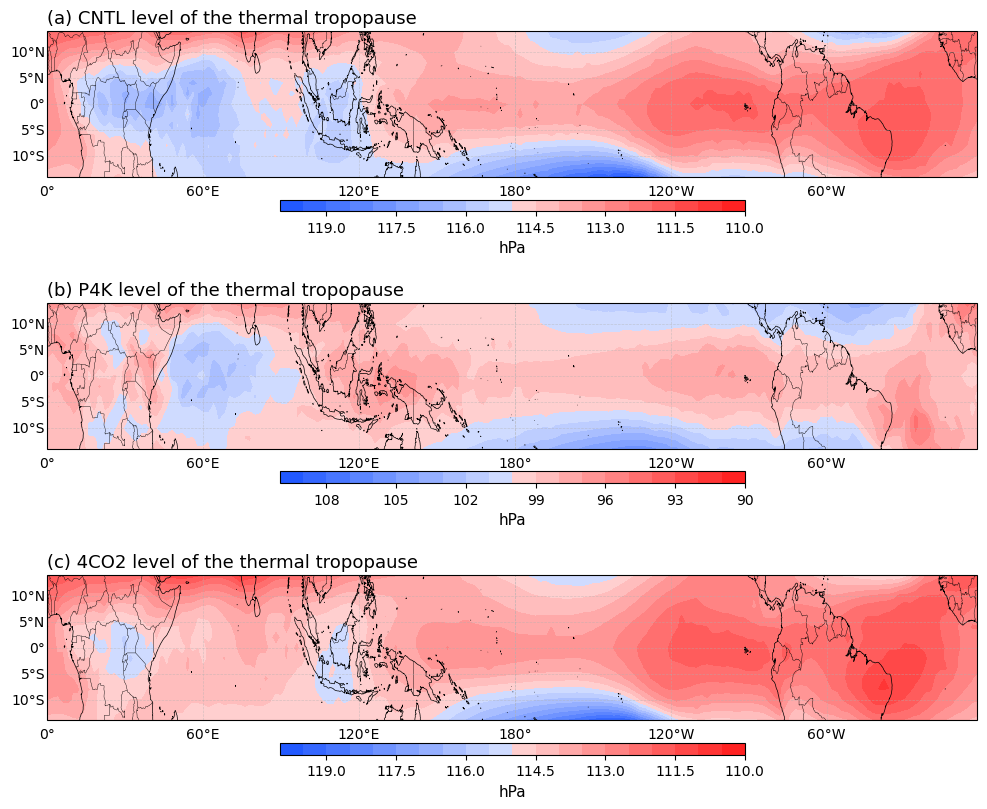

In [12]:


# 投影
proj = ccrs.PlateCarree(180)

fig, axes = plt.subplots(3, 1, figsize=(12, 10), subplot_kw={'projection': proj})

datasets = [
    (ptop_mean_cntl, '(a) CNTL level of the thermal tropopause'),
    (ptop_mean_p4k, '(b) P4K level of the thermal tropopause'),
    (ptop_mean_4co2, '(c) 4CO2 level of the thermal tropopause')
]

# 创建网格 (一次)
lats = ptop_mean_cntl.lat.values
lons = ptop_mean_cntl.lon.values
LON, LAT = np.meshgrid(lons, lats)
# 定义统一 levels
levels = np.arange(85, 125, 5)  # 85 → 120 hPa
  # 覆盖 120→90

for i, (ax, (data, title)) in enumerate(zip(axes, datasets)):
    if i == 0:
        cf = ax.contourf(
            lons, lats, data/100,
            cmap=cmaps.BlueRed_r,
            levels=np.linspace(110,120,21),
            extend='neither',                      # 允许超出范围的 under/over 颜色
            transform=ccrs.PlateCarree()
        )
    elif i==2:
        cf = ax.contourf(
            lons, lats, data/100,               
            cmap=cmaps.BlueRed_r,
            levels=np.linspace(110,120,21),
            extend='neither',                      # 允许超出范围的 under/over 颜色
            transform=ccrs.PlateCarree())
    else:
        cf = ax.contourf(
            lons, lats, data/100,
            cmap=cmaps.BlueRed_r,
            levels=np.linspace(90,110,21),
            extend='neither',                      # 允许超出范围的 under/over 颜色
            transform=ccrs.PlateCarree())
        
    ax.coastlines(linewidth=0.5)
    ax.add_feature(cfeature.BORDERS, linewidth=0.3)
    ax.set_title(title, fontsize=13, loc='left')
    ax.set_aspect(2)

    gl = ax.gridlines(draw_labels=True, linewidth=0.5, alpha=0.5, linestyle='--')
    gl.top_labels = False
    gl.right_labels = False

    cbar = fig.colorbar(cf, ax=ax, orientation='horizontal',
                        pad=0.1, aspect=40, shrink=0.5)

    cbar.set_label('hPa', fontsize=11)
    cbar.ax.invert_xaxis()



# plt.savefig(fig_save_dir + 'tropopause_height_maps.png', dpi=300, bbox_inches='tight')
plt.show()

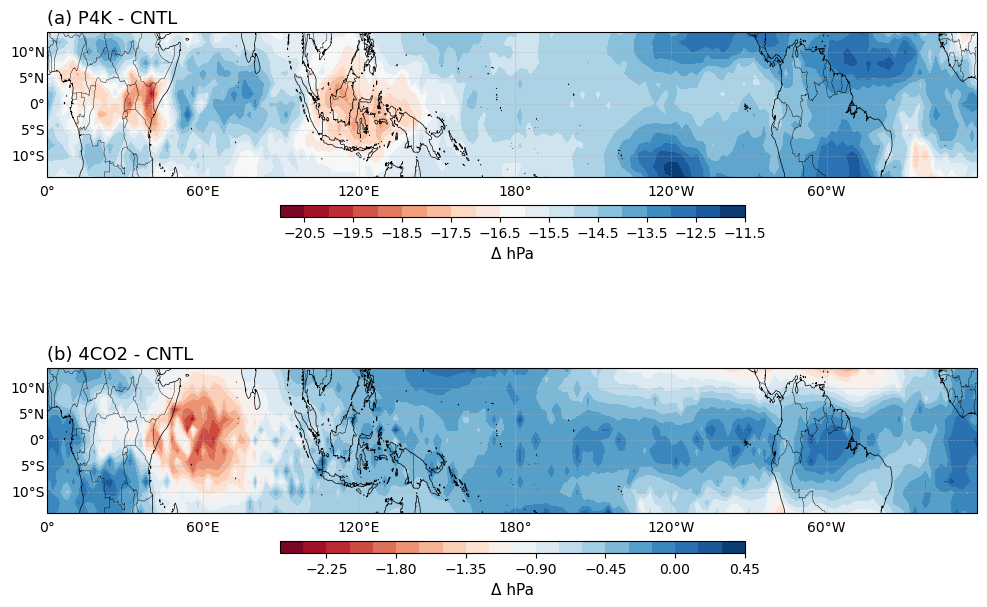

In [13]:


# 投影
proj = ccrs.PlateCarree(180)

fig, axes = plt.subplots(2, 1, figsize=(12, 8), subplot_kw={'projection': proj})

# 差异数据
datasets_diff = [
    (ptop_mean_p4k - ptop_mean_cntl, '(a) P4K - CNTL'),
    (ptop_mean_4co2 - ptop_mean_cntl, '(b) 4CO2 - CNTL')
]

# 创建网格
lats = ptop_mean_cntl.lat.values
lons = ptop_mean_cntl.lon.values
LON, LAT = np.meshgrid(lons, lats)

# 定义差异 colorbar 范围（对称于 0）
vmax = np.max([np.abs(d.values).max() for d, _ in datasets_diff])
levels = 21

for ax, (data_diff, title) in zip(axes, datasets_diff):

    cf = ax.contourf(
        lons, lats, data_diff/100,  # hPa
        levels=levels,
        cmap='RdBu',              # 分散 colormap
        extend='neither',
        transform=ccrs.PlateCarree()
    )

    ax.coastlines(linewidth=0.5)
    ax.add_feature(cfeature.BORDERS, linewidth=0.3)
    ax.set_title(title, fontsize=13, loc='left')
    ax.set_aspect(2)

    gl = ax.gridlines(draw_labels=True, linewidth=0.5, alpha=0.5, linestyle='--')
    gl.top_labels = False
    gl.right_labels = False

    cbar = fig.colorbar(cf, ax=ax, orientation='horizontal', pad=0.1, aspect=40, shrink=0.5)
    cbar.set_label('Δ hPa', fontsize=11)

plt.show()
